# packed_v1 leaderboard — visual weigh-in

Focused view of the `packed_v1` regime (canonical 4k-step horizon).

Two views:
1. **σ-anchored leaderboard** (bar chart): mean ± std per (optimizer, rank) cell, with AdamW's multi-seed σ-band as the reference. Single-seed cells render without error bars.
2. **Trajectory panel** (`standard_sweep_figure`): eval-loss curves over training, with AdamW's seed=0 η-sweep as the left-panel reference.

**σ_AdamW(packed_v1):** 0.0011 at r=16, 0.0017 at r=64 (from `adamw_multiseed_packed_4k_blackwell`, 4 seeds at η=3e-4 + seed=0 lr-sweep). All Δ claims in the writeups should be quoted in σ-units against this anchor.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    standard_sweep_figure,
)
from lora_playground.loader import load_runs, inventory_runs, render_inventory

## Audit — what's loadable vs invisible

In [3]:
print(render_inventory(inventory_runs('../logs')))

Loaded 184 of 195 groups on disk.

NO run_info/ (8) — files present but missing run_info/ dir, invisible to load_runs:
  adamw_sanity_packed_v1_4k
  bench
  bench_a100
  bench_profile_packed_v1
  bench_profile_walltime
  ddp_smoke
  integration_higham_test
  profile_polar_components

UNKNOWN OPTIMIZERS (3) — in logs but missing from OPTIM_COLORS, will be dropped by any cell that filters on it:
  kfac-lora
  svd-cumulative-adamw
  svd-step-adamw

Coverage: 125 (optimizer, rank, mult) cells
PINNED at lr-range boundary (44) — extension sweep recommended:
  adam-clip-product-lora            r=16          best_lr=3e-04 (final=0.7555)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora            r=64          best_lr=3e-04 (final=0.7447)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora-coupled-endrms  r=16          best_lr=3e-04 (final=0.7604)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora-coupled-endrms  r=64          best_lr=3e-04 (final=0.74

## Load packed_v1 runs

Reference = AdamW lr-sweep (seed=0). Candidates = chord/polar variants at lr=3e-3.

In [4]:
# Reference: AdamW packed_v1, ALL seeds. The library aggregates per-η
# (left panel: vertical seed-σ error bars) and per-step at best η (right
# panel: shaded ±σ band around the mean trajectory). Partial-horizon runs
# are auto-filtered (`min_step` inferred from cfg.max_steps).
ref_runs = load_runs(
    where={'optimizer': 'adamw', 'data_pipeline_version': 'packed_v1'},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'reference AdamW packed_v1 (all seeds): {len(ref_runs)} runs')
from collections import Counter
print(f'  seeds per η: ' + ', '.join(
    f"η={lr:.0e}:{n}" for lr, n in
    Counter(cfg['lr'] for cfg, _ in ref_runs).most_common()))

# Candidates: chord/polar family only.
# adam-muon-lora and muon-lora are excluded — at their best lr they sit
# ~+0.012 above AdamW (r=16) and ~+0.010 (r=64), far outside the chord
# variants' Δ range. Including them just stretches plot range / legend
# without informing the chord-vs-AdamW comparison.
CANDIDATE_FAMILY = [
    'adam-polar-product-lora-coupled-spectral-chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening',
    'adam-polar-product-lora-coupled-spectral-chord-direction',
    'adam-polar-product-lora-coupled',  # frob (AdaMuon parent, no chord-tight ρ)
]
cand_runs = load_runs(
    where={'optimizer': CANDIDATE_FAMILY, 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'candidate packed_v1 @ 4k: {len(cand_runs)} runs')
for cfg, evs in cand_runs:
    last = evs[-1] if evs else {}
    pic = cfg.get('_derived', {}).get('effective_picard_iters')
    print(f"  {cfg['optimizer']:55s} r={cfg.get('lora_r')} lr={cfg.get('lr'):.0e} k={pic} "
          f"step={last.get('step')} eval={last.get('eval_loss'):.4f}")


reference AdamW packed_v1 (all seeds): 24 runs
  seeds per η: η=3e-04:10, η=1e-04:6, η=3e-05:3, η=1e-05:2, η=1e-03:2, η=3e-03:1


candidate packed_v1 @ 4k: 81 runs
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=16 lr=1e-03 k=3 step=4000 eval=0.5491
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=64 lr=1e-03 k=3 step=2400 eval=0.5490
  adam-polar-product-lora-coupled-spectral-chord-direction r=16 lr=1e-03 k=3 step=3800 eval=0.5428
  adam-polar-product-lora-coupled-spectral-chord-direction r=64 lr=1e-03 k=3 step=1800 eval=0.5483
  adam-polar-product-lora-coupled-spectral-chord-tight    r=16 lr=3e-02 k=3 step=4000 eval=0.5215
  adam-polar-product-lora-coupled-spectral-chord-tight    r=64 lr=3e-02 k=3 step=2200 eval=0.5286
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=16 lr=3e-02 k=3 step=4000 eval=0.5436
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=64 lr=3e-02 k=3 step=2200 eval=0.5721
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=16 lr=1e-02 k=3 step=4000 eval=0.5211
  adam-polar-product-lora-couple

## Group key and color map

For AdaMuon-parent runs (no chord-tight ρ), distinguish by Picard iter count to separate the `frob_k=1` and `frob_k=3` cells. For chord-family variants the optimizer slug alone is the discriminator.

In [5]:
# Short legend labels with explicit Picard k. Leaderboard now contains both
# k=1 and k=3 cells for the same optimizer slug — always embed k.
SHORT = {
    'adam-polar-product-lora-coupled-spectral-chord-tight':                'chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening':   'chord-tight (no-whiten)',
    'adam-polar-product-lora-coupled-spectral-chord-direction':            'chord-direction',
}


def group_key(cfg):
    """Group label including k where it matters."""
    opt = cfg['optimizer']
    k = cfg.get('_derived', {}).get('effective_picard_iters', '?')
    if opt == 'adam-polar-product-lora-coupled':
        return f'frob k={k}'
    base = SHORT.get(opt, opt)
    return f'{base} k={k}'


# Six maximally-distinct hues — one per (variant, k) in the competitive set.
# Marker shape is also redundantly encoded per variant for mono / colorblind
# readability.
color_map = {
    'chord-tight k=1':              '#1f77b4',  # tab:blue
    'chord-tight k=3':              '#d62728',  # tab:red
    'chord-tight (no-whiten) k=1':  '#17becf',  # tab:cyan
    'chord-tight (no-whiten) k=3':  '#2ca02c',  # tab:green
    'chord-direction k=1':          '#ff7f0e',  # tab:orange
    'chord-direction k=3':          '#9467bd',  # tab:purple
    # frob (supplementary):
    'frob k=1':                     '#bcbd22',  # olive
    'frob k=3':                     '#7f7f7f',  # gray
}

marker_map = {
    'chord-tight k=1':              'o',
    'chord-tight k=3':              'o',
    'chord-tight (no-whiten) k=1':  's',
    'chord-tight (no-whiten) k=3':  's',
    'chord-direction k=1':          'D',
    'chord-direction k=3':          'D',
    'frob k=1':                     '^',
    'frob k=3':                     'v',
}


## Standard sweep figure — competitive vs supplementary

Variant + k split (every lr in the sweep is kept).

- **Competitive**: all six chord-family (variant, k) cells. None is strictly dominated at every rank — at r=64, k=1 and k=3 are tied for no-whiten and direction (Δ ≤ 1σ); the only clear k-dominance is no-whiten at r=16 (k=3 better by ~2.4σ). Six distinct hues, marker shape redundantly encodes variant family.
- **Supplementary**: frob (AdaMuon parent), both k. Different family — kept for context.

NaN / early-killed runs fold into `split_diverged` (NaN eval_loss → ∞; runs that die in the first 10% of training counted as diverged) so they no longer warp the y-axis or sneak into the trajectory panel.


competitive: 77 runs across 43 (variant, k, r, lr) cells
supplementary: 4 runs across 4 (variant, k, r, lr) cells
  [filtered diverged] chord-direction k=3 η=1e-02 max=0.595 final=0.595
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 1 run(s) below min_step=4000:
    chord-direction k=3 η=1e-03    step=3800 final-so-far=0.5428
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 4 run(s) below min_step=4000:
    chord-direction k=3 η=1e-03    step=1800 final-so-far=0.5483
    chord-tight (no-whiten) k=3 η=1e-03 step=2400 final-so-far=0.5490
    chord-tight (no-whiten) k=3 η=3e-02 step=2200 final-so-far=0.5721
    chord-tight k=3 η=3e-02        step=2200 final-so-far=0.5286


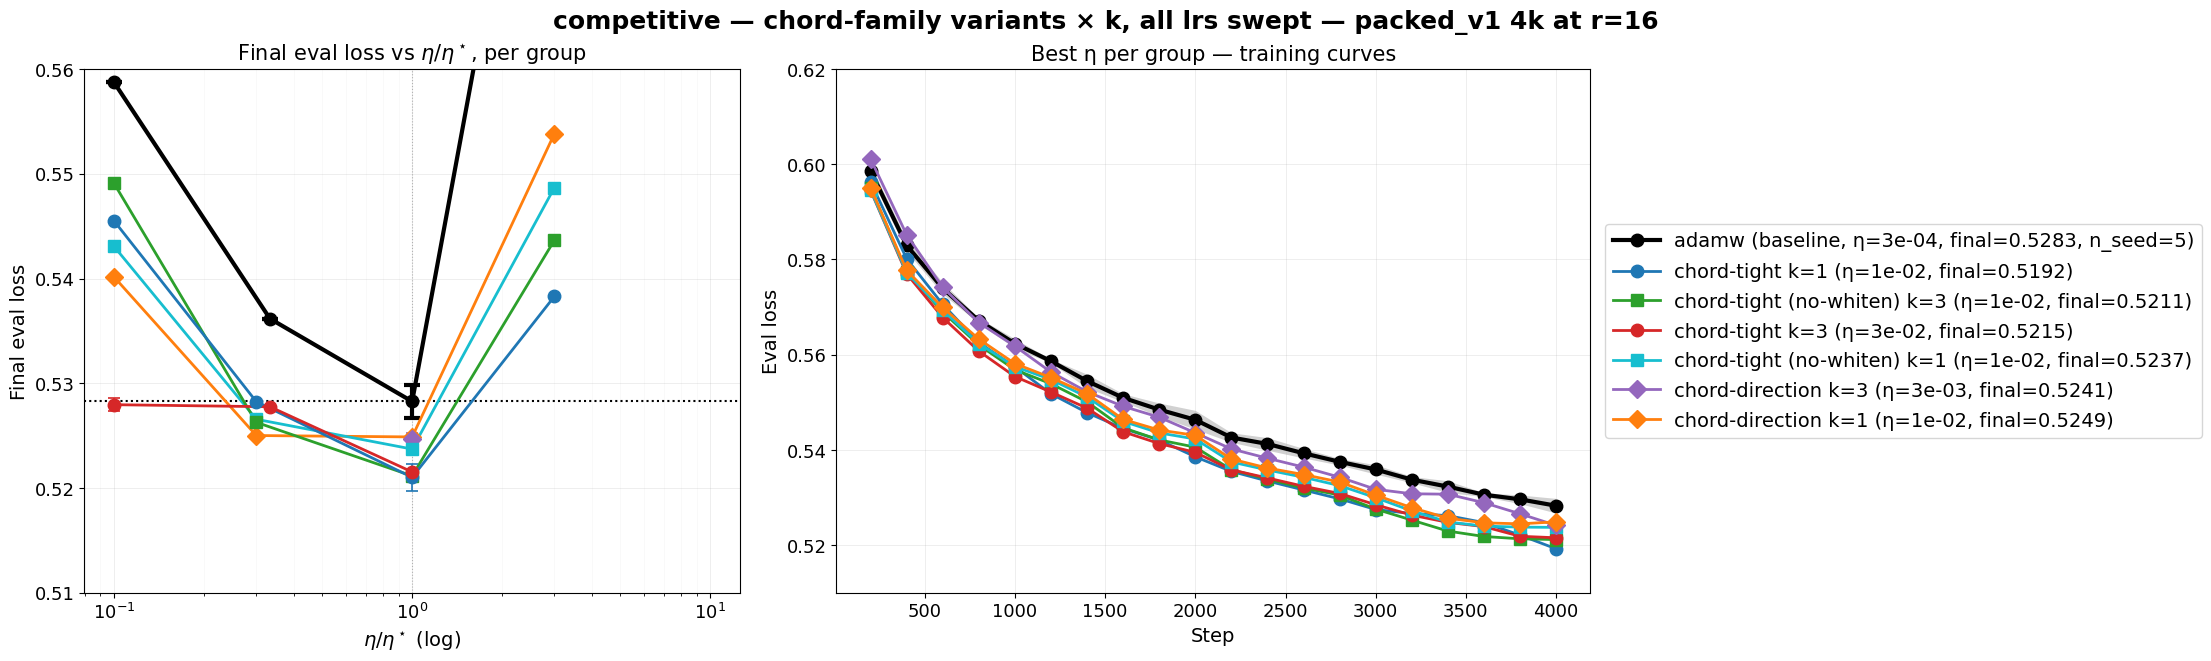

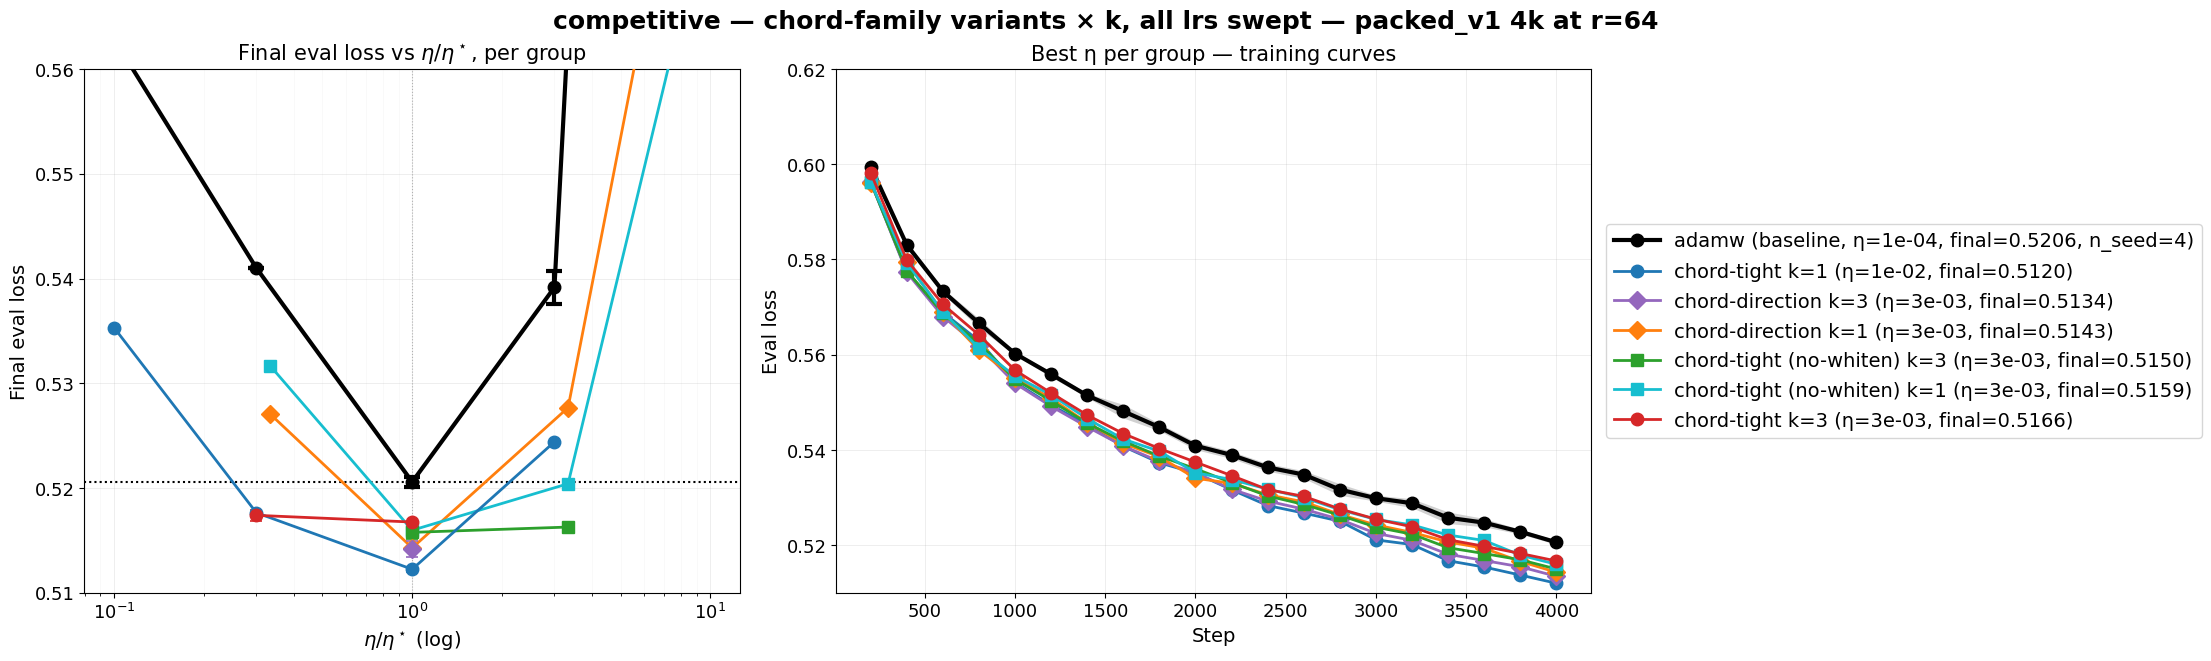

In [6]:
# Competitive / supplementary split by (variant, k). All lrs kept per cell.
# All six chord-family (variant, k) cells stay in competitive — none is
# strictly dominated at every rank. Only the frob parent (different family)
# lives in supplementary.
WHITEN   = 'adam-polar-product-lora-coupled-spectral-chord-tight'
NOWHITEN = 'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening'
DIRECT   = 'adam-polar-product-lora-coupled-spectral-chord-direction'

COMPETITIVE_VARIANT_K = {
    (WHITEN,   1), (WHITEN,   3),
    (NOWHITEN, 1), (NOWHITEN, 3),
    (DIRECT,   1), (DIRECT,   3),
}

def is_competitive(cfg):
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    return (cfg['optimizer'], k) in COMPETITIVE_VARIANT_K

competitive_runs   = [r for r in cand_runs if is_competitive(r[0])]
supplementary_runs = [r for r in cand_runs if not is_competitive(r[0])]

def _cell_count(runs):
    return len({(c['optimizer'],
                 c.get('_derived', {}).get('effective_picard_iters'),
                 c['lora_r'], c['lr']) for c, _ in runs})

print(f'competitive: {len(competitive_runs)} runs across {_cell_count(competitive_runs)} (variant, k, r, lr) cells')
print(f'supplementary: {len(supplementary_runs)} runs across {_cell_count(supplementary_runs)} (variant, k, r, lr) cells')

YLIM_LEFT  = (0.510, 0.560)
YLIM_RIGHT = (0.510, 0.620)

def _render(runs, suptitle):
    results = standard_sweep_figure(
        runs,
        group_key_fn=group_key,
        color_map=color_map,
        reference_runs=ref_runs,
        suptitle=suptitle,
        same_value_axes=('lora_plus_multiplier',),
        marker_map=marker_map,
        figsize=(22, 6.5),
        x_tick_step=500,
        normalize_x_to_optimum=True,
    )
    for fig, axes, _n_keep, _n_drop in results:
        axes[0].set_ylim(*YLIM_LEFT)
        axes[1].set_ylim(*YLIM_RIGHT)
    return results

_render(competitive_runs,
        'competitive — chord-family variants × k, all lrs swept — packed_v1 4k')
plt.show()


### Supplementary — frob parent

`adam-polar-product-lora-coupled` (frob / AdaMuon parent, no chord-tight ρ). Different family from the chord variants — context only.


  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000


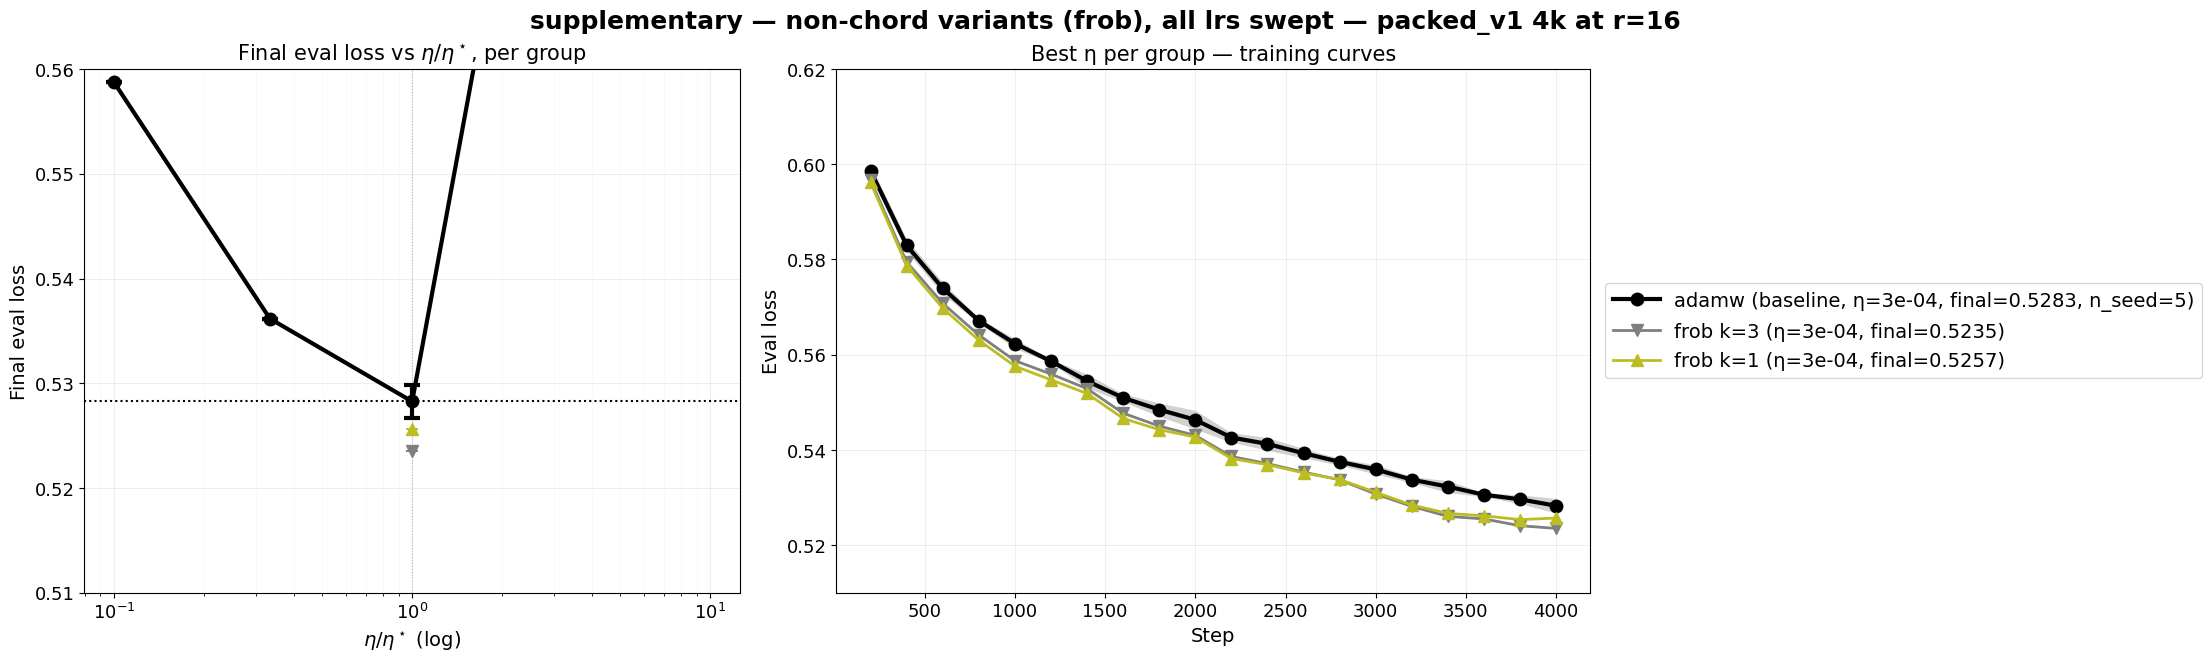

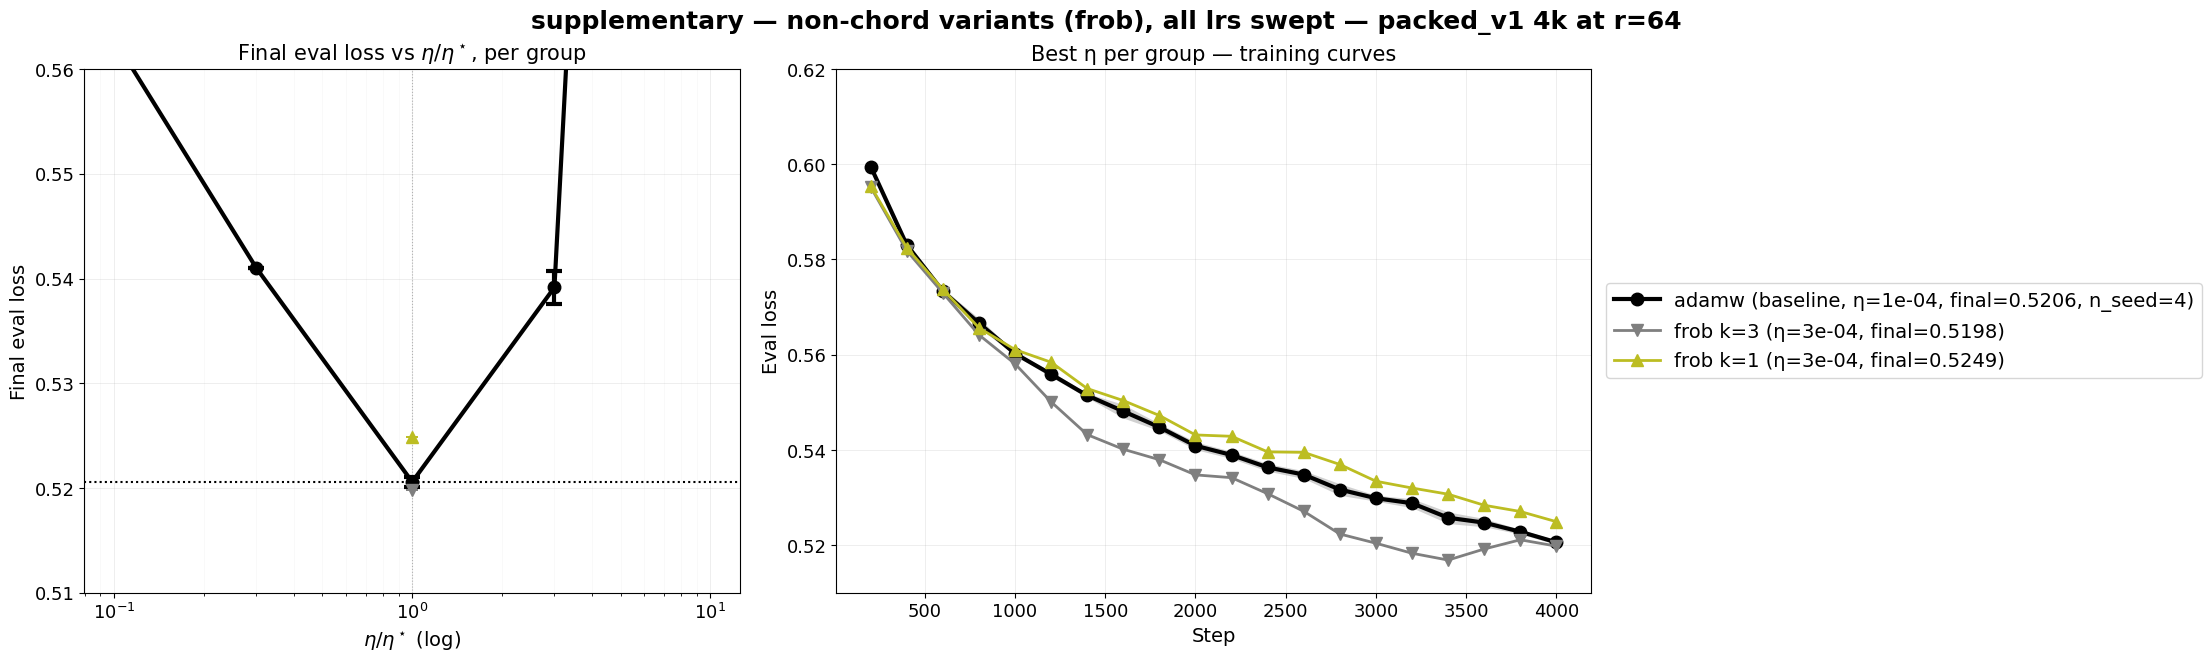

In [7]:
_render(supplementary_runs,
        'supplementary — non-chord variants (frob), all lrs swept — packed_v1 4k')
plt.show()


## Rescaled Picard: k=1 vs k=3 within L'

Apples-to-apples comparison of the rescaled-Picard variant in isolation. All four runs come from a single sweep group (`chord_tight_picard_unit_polar_k1k3_lr1e-2_4k_r16r64_blackwell`, commit `36abd11`, unit-polar normalization + `2/(ρ·s)` coefficient): same code, same lr=1e-2, same seed=0. Only `picard_iters` differs (k=1 = off, k=3 = active).

After the diagnostic fix (γ now uses the applied `2/(ρ·s)` coefficient and the post-unit-polar ū_A as denominator), γ for these k=3 runs is order-1 in polar-input space — Picard is genuinely rotating the polar direction, not a no-op.


L' runs: 4
  r=16 k=1 step=4000 eval=0.5222
  r=16 k=3 step=4000 eval=0.5278
  r=64 k=1 step=4000 eval=0.5122
  r=64 k=3 step=4000 eval=0.5167


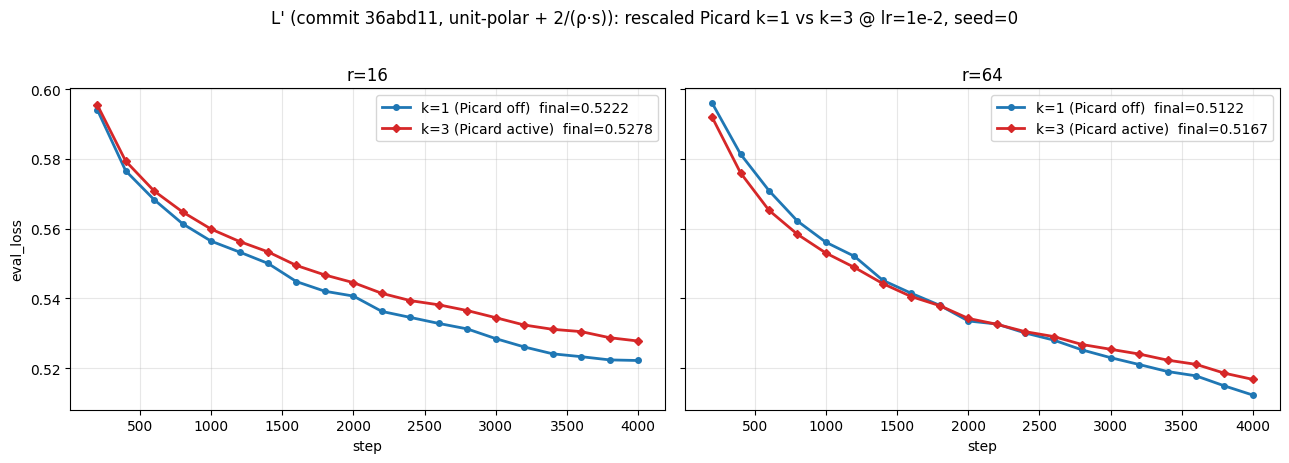


Δ summary (k=3 minus k=1, σ_AdamW context: r=16 → 0.0011, r=64 → 0.0017):
  r=16: k=1 0.5222  k=3 0.5278  Δ +0.0056  (+5.1σ)
  r=64: k=1 0.5122  k=3 0.5167  Δ +0.0045  (+2.6σ)


In [8]:
# Isolated L' load — group filter pins to commit 36abd11 only.
lp_runs = load_runs(
    where={'log_group': 'chord_tight_picard_unit_polar_k1k3_lr1e-2_4k_r16r64_blackwell'},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'L\' runs: {len(lp_runs)}')
for cfg, evs in sorted(lp_runs, key=lambda r: (r[0]['lora_r'], r[0].get('_derived', {}).get('effective_picard_iters'))):
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    last = evs[-1]
    print(f"  r={cfg['lora_r']} k={k} step={last['step']} eval={last['eval_loss']:.4f}")

# Single-axis trajectory plot per rank: k=1 (off) vs k=3 (active) at lr=1e-2.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
LP_COLORS = {1: '#1f77b4', 3: '#d62728'}  # blue = off, red = active
for ax, r_target in zip(axes, [16, 64]):
    for cfg, evs in lp_runs:
        if cfg['lora_r'] != r_target:
            continue
        k = cfg.get('_derived', {}).get('effective_picard_iters')
        steps = [e['step'] for e in evs]
        losses = [e['eval_loss'] for e in evs]
        ax.plot(steps, losses, color=LP_COLORS[k], lw=2.0,
                marker='o' if k == 1 else 'D', markersize=4,
                label=f"k={k} (Picard {'off' if k == 1 else 'active'})  final={losses[-1]:.4f}")
    ax.set_title(f'r={r_target}')
    ax.set_xlabel('step')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
axes[0].set_ylabel('eval_loss')
fig.suptitle("L' (commit 36abd11, unit-polar + 2/(ρ·s)): rescaled Picard k=1 vs k=3 @ lr=1e-2, seed=0",
             y=1.02)
fig.tight_layout()
plt.show()

# Δ summary table.
print()
print('Δ summary (k=3 minus k=1, σ_AdamW context: r=16 → 0.0011, r=64 → 0.0017):')
finals = {}
for cfg, evs in lp_runs:
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    finals[(cfg['lora_r'], k)] = evs[-1]['eval_loss']
for r in [16, 64]:
    sigma = 0.0011 if r == 16 else 0.0017
    delta = finals[(r, 3)] - finals[(r, 1)]
    print(f"  r={r}: k=1 {finals[(r,1)]:.4f}  k=3 {finals[(r,3)]:.4f}  Δ {delta:+.4f}  ({delta/sigma:+.1f}σ)")


## r=256 extension

Fresh rank. AdamW r=256 lr-sweep already done (job 6395477). Chord-family r=256 sweeps re-launched against commit `fe035ce` (dynamic batched/per-pair path selection) after the original submission hit a per-pair-path slowdown.

This cell auto-includes whatever packed_v1 data exists at r=256 — AdamW now, chord-family as it lands.


r=256 packed_v1 runs: 4
  adamw                            lr=1e-05 step= 4000 eval=0.5444
  adamw                            lr=3e-05 step= 4000 eval=0.5221
  adamw                            lr=1e-04 step= 4000 eval=0.5205
  adamw                            lr=3e-04 step= 4000 eval=0.6219


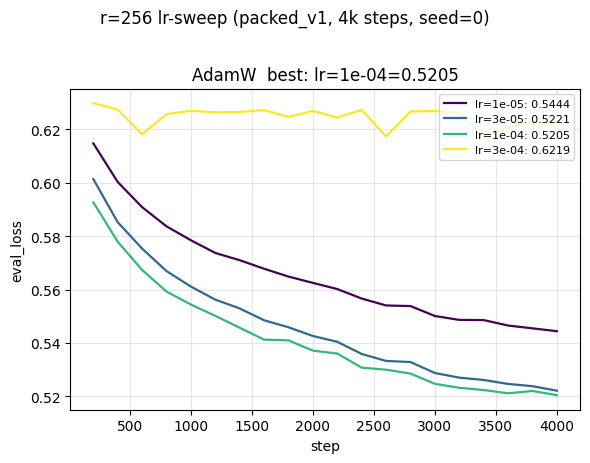

In [9]:
# Pull packed_v1 r=256 data for both AdamW and chord-family.
ALL_R256_OPTS = ['adamw'] + CANDIDATE_FAMILY
r256_runs = load_runs(
    where={'optimizer': ALL_R256_OPTS, 'data_pipeline_version': 'packed_v1',
           'lora_r': 256},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'r=256 packed_v1 runs: {len(r256_runs)}')
for cfg, evs in sorted(r256_runs,
                        key=lambda r: (r[0]['optimizer'], float(r[0]['lr']))):
    if not evs: continue
    last = evs[-1]
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    opt_short = cfg['optimizer'].replace(
        'adam-polar-product-lora-coupled-spectral-', '').replace(
        'adam-polar-product-lora-coupled', 'frob')
    k_tag = f" k={k}" if cfg['optimizer'] != 'adamw' else ''
    print(f"  {opt_short:32s}{k_tag} lr={cfg['lr']:.0e} step={last['step']:5d} "
          f"eval={last['eval_loss']:.4f}")

# Trajectory plot — one panel per optimizer family, lr-sweep within each.
# Group by optimizer name (one curve per lr).
from collections import defaultdict
by_opt = defaultdict(list)
for cfg, evs in r256_runs:
    if not evs: continue
    by_opt[cfg['optimizer']].append((cfg, evs))

# Plot setup: variable number of panels depending on how many optimizers have data
n_panels = len(by_opt)
if n_panels == 0:
    print("\nNo r=256 data yet — chord jobs still compiling.")
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4.5),
                              sharey=True, squeeze=False)
    axes = axes[0]
    SHORT_R256 = {
        'adamw': 'AdamW',
        'adam-polar-product-lora-coupled-spectral-chord-tight': 'chord-tight (whiten)',
        'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening': 'chord-tight (no-whiten)',
        'adam-polar-product-lora-coupled-spectral-chord-direction': 'chord-direction',
        'adam-polar-product-lora-coupled': 'frob',
    }
    # Order: AdamW first, then chord variants alphabetically.
    opt_order = ['adamw'] + sorted(
        [o for o in by_opt if o != 'adamw'])
    cmap = plt.cm.viridis
    for ax, opt in zip(axes, opt_order):
        runs_for_opt = sorted(by_opt[opt], key=lambda r: float(r[0]['lr']))
        lrs = sorted({float(c['lr']) for c, _ in runs_for_opt})
        lr_to_color = {lr: cmap(i / max(1, len(lrs) - 1))
                       for i, lr in enumerate(lrs)}
        best_final = float('inf'); best_lr = None
        for cfg, evs in runs_for_opt:
            lr = float(cfg['lr'])
            steps = [e['step'] for e in evs]
            losses = [e['eval_loss'] for e in evs]
            label_extra = ''
            if evs[-1]['step'] < cfg.get('max_steps', 4000):
                label_extra = f" (partial @ {evs[-1]['step']})"
            ax.plot(steps, losses, color=lr_to_color[lr], lw=1.6,
                    label=f"lr={lr:.0e}: {losses[-1]:.4f}{label_extra}")
            if (evs[-1]['step'] >= cfg.get('max_steps', 4000)
                    and losses[-1] < best_final):
                best_final = losses[-1]; best_lr = lr
        ax.set_title(f'{SHORT_R256.get(opt, opt)}' +
                     (f'  best: lr={best_lr:.0e}={best_final:.4f}'
                      if best_lr is not None else ''))
        ax.set_xlabel('step')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)
    axes[0].set_ylabel('eval_loss')
    fig.suptitle('r=256 lr-sweep (packed_v1, 4k steps, seed=0)', y=1.02)
    fig.tight_layout()
    plt.show()
